
Training SVM without PCA...
Training SVM with PCA...

Training NaiveBayes without PCA...
Training NaiveBayes with PCA...

Training KNN without PCA...
Training KNN with PCA...

Training LogisticRegression without PCA...
Training LogisticRegression with PCA...

Training DecisionTree without PCA...
Training DecisionTree with PCA...

Training RandomForest without PCA...
Training RandomForest with PCA...

Training AdaBoost without PCA...
Training AdaBoost with PCA...

Training GradientBoosting without PCA...
Training GradientBoosting with PCA...

Training XGBoost without PCA...


c:\Users\madhu\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [09:37:01] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Training XGBoost with PCA...


c:\Users\madhu\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [09:37:03] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Training Stacking without PCA...
Training Stacking with PCA...

=== Model Evaluation Comparison (First 5 Models) ===
                    Accuracy           Precision              Recall  \
Setting               No PCA  With PCA    No PCA  With PCA    No PCA   
Model                                                                  
AdaBoost            0.926167  0.890337  0.937500  0.898072  0.884615   
DecisionTree        0.926167  0.895765  0.935135  0.890957  0.887179   
GradientBoosting    0.945711  0.932682  0.961957  0.943243  0.907692   
KNN                 0.891422  0.895765  0.883598  0.886842  0.856410   
LogisticRegression  0.919653  0.916395  0.931694  0.928767  0.874359   

                              F1 Score            
Setting             With PCA    No PCA  With PCA  
Model                                             
AdaBoost            0.835897  0.910290  0.865870  
DecisionTree        0.858974  0.910526  0.874674  
GradientBoosting    0.894872  0.934037  0.918421  

<Figure size 1200x600 with 0 Axes>

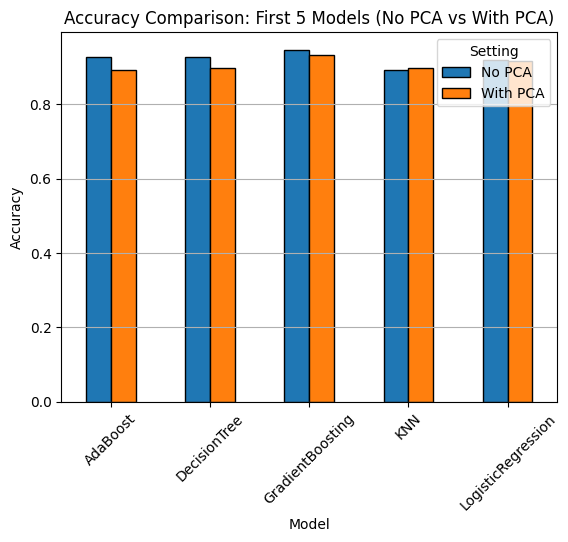

<Figure size 1200x600 with 0 Axes>

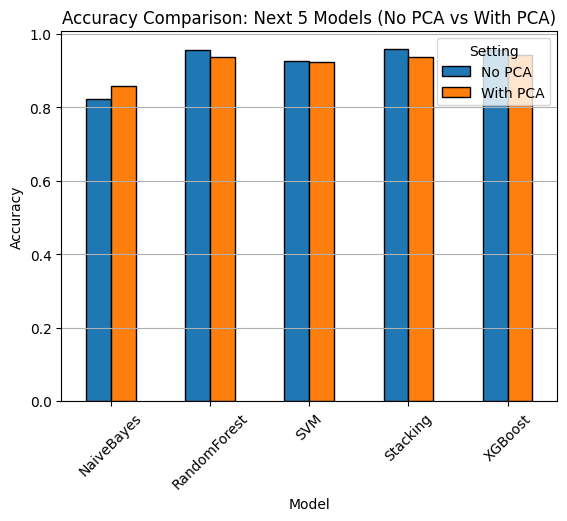

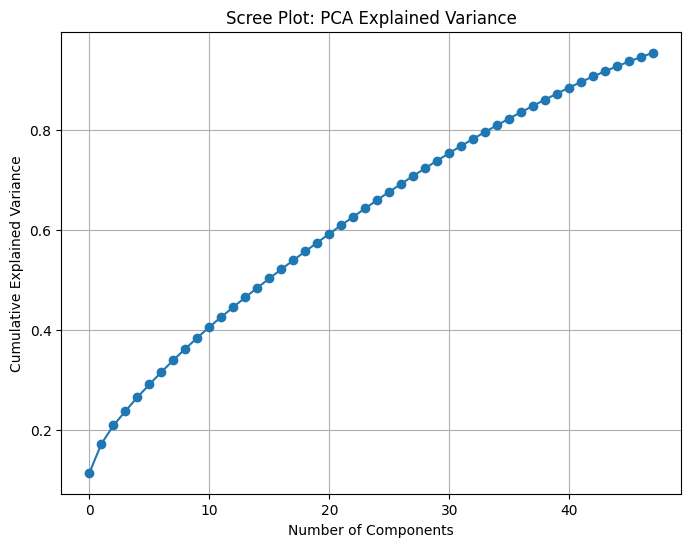

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier, RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Load dataset
data = pd.read_csv(r"C:/Users/madhu/OneDrive/Desktop/ML-3/spambase_csv.csv")

# Features and target
X = data.drop(columns=['class'])
y = data['class']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Preprocessing and PCA
scaler = StandardScaler()
pca = PCA(n_components=0.95, random_state=42)

# Define models with optimized hyperparameter grids
models = {
    'SVM': (SVC(), {'model__C': [1], 'model__kernel': ['linear']}),
    'NaiveBayes': (GaussianNB(), {}),
    'KNN': (KNeighborsClassifier(), {'model__n_neighbors': [3]}),
    'LogisticRegression': (LogisticRegression(max_iter=1000), {'model__C': [1]}),
    'DecisionTree': (DecisionTreeClassifier(random_state=42), {'model__max_depth': [10]}),
    'RandomForest': (RandomForestClassifier(random_state=42), {'model__n_estimators': [100]}),
    'AdaBoost': (AdaBoostClassifier(random_state=42), {'model__n_estimators': [50]}),
    'GradientBoosting': (GradientBoostingClassifier(random_state=42), {'model__n_estimators': [100]}),
    'XGBoost': (XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42), {'model__n_estimators': [100]}),
    'Stacking': (StackingClassifier(estimators=[
        ('rf', RandomForestClassifier(random_state=42)),
        ('svc', SVC(probability=True, random_state=42)),
        ('knn', KNeighborsClassifier())
    ], final_estimator=LogisticRegression(max_iter=1000), n_jobs=-1), {})
}

results = []

for model_name, (model, param_grid) in models.items():
    print(f"\nTraining {model_name} without PCA...")
    
    # Pipeline without PCA
    pipe = Pipeline([
        ('scaler', scaler),
        ('model', model)
    ])
    
    grid = GridSearchCV(pipe, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
    grid.fit(X_train, y_train)
    
    y_pred = grid.best_estimator_.predict(X_test)
    
    results.append({
        'Model': model_name,
        'Setting': 'No PCA',
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1 Score': f1_score(y_test, y_pred)
    })
    
    print(f"Training {model_name} with PCA...")
    
    pipe_pca = Pipeline([
        ('scaler', scaler),
        ('pca', pca),
        ('model', model)
    ])
    
    grid_pca = GridSearchCV(pipe_pca, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
    grid_pca.fit(X_train, y_train)
    
    y_pred_pca = grid_pca.best_estimator_.predict(X_test)
    
    results.append({
        'Model': model_name,
        'Setting': 'With PCA',
        'Accuracy': accuracy_score(y_test, y_pred_pca),
        'Precision': precision_score(y_test, y_pred_pca),
        'Recall': recall_score(y_test, y_pred_pca),
        'F1 Score': f1_score(y_test, y_pred_pca)
    })

# Convert results to DataFrame
results_df = pd.DataFrame(results)

# Pivot table for comparison
pivot_df = results_df.pivot(index='Model', columns='Setting')[['Accuracy', 'Precision', 'Recall', 'F1 Score']]

# Split into two tables
first_half = pivot_df.iloc[:5]
second_half = pivot_df.iloc[5:]

print("\n=== Model Evaluation Comparison (First 5 Models) ===")
print(first_half)

print("\n=== Model Evaluation Comparison (Next 5 Models) ===")
print(second_half)

# Plot Accuracy Comparison
plt.figure(figsize=(12, 6))
first_half['Accuracy'].plot(kind='bar', edgecolor='black')
plt.title('Accuracy Comparison: First 5 Models (No PCA vs With PCA)')
plt.ylabel('Accuracy')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.legend(title='Setting')
plt.show()

plt.figure(figsize=(12, 6))
second_half['Accuracy'].plot(kind='bar', edgecolor='black')
plt.title('Accuracy Comparison: Next 5 Models (No PCA vs With PCA)')
plt.ylabel('Accuracy')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.legend(title='Setting')
plt.show()

# PCA Scree Plot
pca_full = Pipeline([
    ('scaler', scaler),
    ('pca', PCA(n_components=0.95, random_state=42))
])
X_transformed = pca_full.fit_transform(X_train)
explained_variance = pca_full.named_steps['pca'].explained_variance_ratio_

plt.figure(figsize=(8, 6))
plt.plot(np.cumsum(explained_variance), marker='o')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Scree Plot: PCA Explained Variance')
plt.grid(True)
plt.show()
